---
# Heart disease - classification problem
## In this project, I show my work as well as my thought process.
---


## Exploratory Data Analysis
-----

In [1]:
import pandas as pd
import seaborn as sns

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.impute import KNNImputer
from sklearn.impute import SimpleImputer

--- ---
# Data Wrangling

In [2]:
data = pd.read_csv("heart_disease_uci.csv")
data.drop(columns="id", inplace=True)
data.head()
original_data_copied = data.copy()

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       920 non-null    int64  
 1   sex       920 non-null    object 
 2   dataset   920 non-null    object 
 3   cp        920 non-null    object 
 4   trestbps  861 non-null    float64
 5   chol      890 non-null    float64
 6   fbs       830 non-null    object 
 7   restecg   918 non-null    object 
 8   thalch    865 non-null    float64
 9   exang     865 non-null    object 
 10  oldpeak   858 non-null    float64
 11  slope     611 non-null    object 
 12  ca        309 non-null    float64
 13  thal      434 non-null    object 
 14  num       920 non-null    int64  
dtypes: float64(5), int64(2), object(8)
memory usage: 107.9+ KB


In [4]:
data.shape

(920, 15)

### In order to process Machine Learning I have to binarize some categorical data at first ( I will use hot encoding, because is not any hierarchical relationship ).

In [5]:
sex_binarization_cat = pd.get_dummies(data=data["sex"])
sex_binarization_cat = sex_binarization_cat.astype(int)
sex_binarization_cat.head()

,Female,Male
0,0,1
1,0,1
2,0,1
3,0,1
4,1,0


In [6]:
data.drop(columns="sex", inplace=True)
data = pd.concat([data, sex_binarization_cat], axis=1)
data

,age,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num,Female,Male
0,63,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0,0,1
1,67,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2,0,1
2,67,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1,0,1
3,37,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0,0,1
4,41,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
915,54,VA Long Beach,asymptomatic,127.0,333.0,True,st-t abnormality,154.0,False,0.0,NaN,NaN,NaN,1,1,0
916,62,VA Long Beach,typical angina,NaN,139.0,False,st-t abnormality,NaN,NaN,NaN,NaN,NaN,NaN,0,0,1
917,55,VA Long Beach,asymptomatic,122.0,223.0,True,st-t abnormality,100.0,False,0.0,NaN,NaN,fixed defect,2,0,1
918,58,VA Long Beach,asymptomatic,NaN,385.0,True,lv hypertrophy,NaN,NaN,NaN,NaN,NaN,NaN,0,0,1


In [7]:
data["dataset"].value_counts()

dataset
Cleveland        304
Hungary          293
VA Long Beach    200
Switzerland      123
Name: count, dtype: int64

### Because there are only 4 datasets (unique_vals) It is okay to binarize it as well.
## I will do that, because I assume that this column might have big impact on trustworthiness of this Project (because Hospitals where data come from are located in different regions around the globe).

In [8]:
dataset_origin = pd.get_dummies(data = data["dataset"], prefix="data")
dataset_origin.rename(columns={"data_VA Long Beach": "data_California"}, inplace=True)
dataset_origin = dataset_origin.astype(int)

data.drop(columns="dataset", inplace=True)
data = pd.concat([data, dataset_origin], axis=1)
data.head()

,age,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num,Female,Male,data_Cleveland,data_Hungary,data_Switzerland,data_California
0,63,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0,0,1,1,0,0,0
1,67,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2,0,1,1,0,0,0
2,67,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1,0,1,1,0,0,0
3,37,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0,0,1,1,0,0,0
4,41,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0,1,0,1,0,0,0


# Now I will binarize column **cp** (which describes chest pain types) in a hierarchical way to see relations between the levels of pain which would be impossible to obtain if we do regular binarization which divide records independantly)

* **Chest pain - hierarchical binarization** (`cp`)
    * `is_symptomatic` ("typical angina", "atypical angina", "non-anginal")
        * `is_anginal` ("typical angina", "atypical angina",)
            * `is_typical` ("typical angina")

In [9]:
data["cp"].value_counts()

cp
asymptomatic       496
non-anginal        204
atypical angina    174
typical angina      46
Name: count, dtype: int64

In [10]:
data['is_symptomatic'] = data['cp'].apply(lambda x: 1 if x != "asymptomatic" else 0)

# if there is chest pain
anginal_types = ["typical angina", "atypical angina"]
data['is_anginal'] = data['cp'].isin(anginal_types).astype(int)

data['is_typical'] = (data['cp'] == "typical angina").astype(int)

data.drop(columns="cp", inplace=True)
data.head()

,age,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,...,num,Female,Male,data_Cleveland,data_Hungary,data_Switzerland,data_California,is_symptomatic,is_anginal,is_typical
0,63,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,...,0,0,1,1,0,0,0,1,1,1
1,67,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,...,2,0,1,1,0,0,0,0,0,0
2,67,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,...,1,0,1,1,0,0,0,0,0,0
3,37,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,...,0,0,1,1,0,0,0,1,0,0
4,41,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,...,0,1,0,1,0,0,0,1,1,0


---
# Missing Values

# Now I will handle few columns starting with trestbps which stands for resting blood presure are missing values. There is quite a lot NaNs in this column. I choose the Iterative Imputer technique (MICE -> Multivariate Imputation by Chained Equations). 
## Justification:
## Because my dataset have samples (patients data) from different locations I want to have regard to this characteristics. I will choose trestbps column as a dependant variable and the rest columns will build a regression model to fit missing vals. Then in the next step of iteration the dependant variable will be next 

# I do realize that filling missing values like that should be verified and consulted with the field expert. 

In [11]:
def check_table_nulls():
    for col in data.columns:
        print(data[col].isnull().value_counts())
check_table_nulls()

age
False    920
Name: count, dtype: int64
trestbps
False    861
True      59
Name: count, dtype: int64
chol
False    890
True      30
Name: count, dtype: int64
fbs
False    830
True      90
Name: count, dtype: int64
restecg
False    918
True       2
Name: count, dtype: int64
thalch
False    865
True      55
Name: count, dtype: int64
exang
False    865
True      55
Name: count, dtype: int64
oldpeak
False    858
True      62
Name: count, dtype: int64
slope
False    611
True     309
Name: count, dtype: int64
ca
True     611
False    309
Name: count, dtype: int64
thal
True     486
False    434
Name: count, dtype: int64
num
False    920
Name: count, dtype: int64
Female
False    920
Name: count, dtype: int64
Male
False    920
Name: count, dtype: int64
data_Cleveland
False    920
Name: count, dtype: int64
data_Hungary
False    920
Name: count, dtype: int64
data_Switzerland
False    920
Name: count, dtype: int64
data_California
False    920
Name: count, dtype: int64
is_symptomatic
False    92

# I assume that this columns below will be the most influential on the missing values. In this set of columns there are others which have missing vals as well and this technique will fulfill each missing val from any colunmn. The last 2 cols are very important ones to help in imputation.

In [12]:
cols_to_use = ['age', 'trestbps', 'chol', 'oldpeak', 'is_symptomatic', 'is_anginal']

imputer = IterativeImputer(random_state=42)
data[cols_to_use] = imputer.fit_transform(data[cols_to_use])


----
##  Now I will handle boolean columns with missing values: 
### * fbs -> (if fasting blood sugar > 120 mg/dl
### * exang -> induced angina by exercise

## In both cols missing values are over 5% of whole column so I am going to proceed Iterative imputation, but because this method is a regression, I will specify threshold value to apply binarization.

As we can see 1 Hospital usually did not note this fbs parameter. It is 60% null so we cannot use this Iterative imputation approach because we risk that model is going to learn very inaccurate formulas and will give fake outputs.

In [13]:
fbs_analysis = original_data_copied.groupby('dataset')['fbs'].apply(lambda x: x.isnull().mean() * 100)
print(fbs_analysis)

dataset
Cleveland         0.000000
Hungary           2.730375
Switzerland      60.975610
VA Long Beach     3.500000
Name: fbs, dtype: float64


## I want to avoid dropping this column. Instead I will fill missing vals with zeros, but I will create another column to tell the model where I filled missing values.

In [14]:
data['fbs_was_missing'] = data['fbs'].isnull().astype(int)

data['fbs'] = data['fbs'].fillna(0)
data[["fbs", "trestbps", "chol"]] = data[["fbs", "trestbps", "chol"]].astype(int)
data.head()

,age,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,...,Female,Male,data_Cleveland,data_Hungary,data_Switzerland,data_California,is_symptomatic,is_anginal,is_typical,fbs_was_missing
0,63.0,145,233,1,lv hypertrophy,150.0,False,2.3,downsloping,0.0,...,0,1,1,0,0,0,1.0,1.0,1,0
1,67.0,160,286,0,lv hypertrophy,108.0,True,1.5,flat,3.0,...,0,1,1,0,0,0,0.0,0.0,0,0
2,67.0,120,229,0,lv hypertrophy,129.0,True,2.6,flat,2.0,...,0,1,1,0,0,0,0.0,0.0,0,0
3,37.0,130,250,0,normal,187.0,False,3.5,downsloping,0.0,...,0,1,1,0,0,0,1.0,0.0,0,0
4,41.0,130,204,0,lv hypertrophy,172.0,False,1.4,upsloping,0.0,...,1,0,1,0,0,0,1.0,1.0,0,0


In [15]:
exang_analysis = original_data_copied.groupby('dataset')['exang'].apply(lambda x: x.isnull().mean() * 100)
print(exang_analysis)

dataset
Cleveland         0.000000
Hungary           0.341297
Switzerland       0.813008
VA Long Beach    26.500000
Name: exang, dtype: float64


## This 'exang' column looks different. Here I will choose KNN Imputer, but again I will create another column just to signal my model that I evaluated this values. I chose the best predictor cols based on empirical evidence.


In [16]:
data['exang_was_missing'] = data['exang'].isnull().astype(int)
cols_for_knn = ['exang', 'thalch', 'oldpeak', 'age', 'is_symptomatic', 'is_anginal']

knn_imputer = KNNImputer(n_neighbors=5)
data[cols_for_knn] = knn_imputer.fit_transform(data[cols_for_knn])

data['exang'] = data['exang'].round().astype(int)
data["exang"] = data["exang"].astype(int)
data["age"] = data["age"].astype(int)
data.head()

,age,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,...,Male,data_Cleveland,data_Hungary,data_Switzerland,data_California,is_symptomatic,is_anginal,is_typical,fbs_was_missing,exang_was_missing
0,63,145,233,1,lv hypertrophy,150.0,0,2.3,downsloping,0.0,...,1,1,0,0,0,1.0,1.0,1,0,0
1,67,160,286,0,lv hypertrophy,108.0,1,1.5,flat,3.0,...,1,1,0,0,0,0.0,0.0,0,0,0
2,67,120,229,0,lv hypertrophy,129.0,1,2.6,flat,2.0,...,1,1,0,0,0,0.0,0.0,0,0,0
3,37,130,250,0,normal,187.0,0,3.5,downsloping,0.0,...,1,1,0,0,0,1.0,0.0,0,0,0
4,41,130,204,0,lv hypertrophy,172.0,0,1.4,upsloping,0.0,...,0,1,0,0,0,1.0,1.0,0,0,0


## Another column 'restecg' -> resting electrocardiographic results has only 2 missing values so it is not statistically important. I will replace it by most frequent values

In [17]:
imputer = SimpleImputer(strategy='most_frequent')
data[['restecg']] = imputer.fit_transform(data[['restecg']])

### For binarization this column I will apply hierarchical model: abnormal and hypertrophy categories which suggests that it is more serious case than abnormality which may be caused genetically.

In [18]:
data['ecg_abnormal'] = data['restecg'].apply(lambda x: 1 if x in ['stt abnormality', 'lv hypertrophy'] else 0)
data['ecg_lvh'] = (data['restecg'] == 'lv hypertrophy').astype(int)
data.drop(columns="restecg", inplace=True)
data[["age", "trestbps", "chol","thalch"]] = data[["age", "trestbps", "chol","thalch"]].astype(int)
data.head()

,age,trestbps,chol,fbs,thalch,exang,oldpeak,slope,ca,thal,...,data_Hungary,data_Switzerland,data_California,is_symptomatic,is_anginal,is_typical,fbs_was_missing,exang_was_missing,ecg_abnormal,ecg_lvh
0,63,145,233,1,150,0,2.3,downsloping,0.0,fixed defect,...,0,0,0,1.0,1.0,1,0,0,1,1
1,67,160,286,0,108,1,1.5,flat,3.0,normal,...,0,0,0,0.0,0.0,0,0,0,1,1
2,67,120,229,0,129,1,2.6,flat,2.0,reversable defect,...,0,0,0,0.0,0.0,0,0,0,1,1
3,37,130,250,0,187,0,3.5,downsloping,0.0,normal,...,0,0,0,1.0,0.0,0,0,0,0,0
4,41,130,204,0,172,0,1.4,upsloping,0.0,normal,...,0,0,0,1.0,1.0,0,0,0,1,1


In [19]:
thal_analysis = original_data_copied.groupby('dataset')['thal'].apply(lambda x: x.isnull().mean() * 100)
print(thal_analysis)

dataset
Cleveland         0.986842
Hungary          90.443686
Switzerland      42.276423
VA Long Beach    83.000000
Name: thal, dtype: float64


In [20]:
data.dtypes

age                    int64
trestbps               int64
chol                   int64
fbs                    int64
thalch                 int64
exang                  int64
oldpeak              float64
slope                 object
ca                   float64
thal                  object
num                    int64
Female                 int64
Male                   int64
data_Cleveland         int64
data_Hungary           int64
data_Switzerland       int64
data_California        int64
is_symptomatic       float64
is_anginal           float64
is_typical             int64
fbs_was_missing        int64
exang_was_missing      int64
ecg_abnormal           int64
ecg_lvh                int64
dtype: object

In [21]:
check_table_nulls()

age
False    920
Name: count, dtype: int64
trestbps
False    920
Name: count, dtype: int64
chol
False    920
Name: count, dtype: int64
fbs
False    920
Name: count, dtype: int64
thalch
False    920
Name: count, dtype: int64
exang
False    920
Name: count, dtype: int64
oldpeak
False    920
Name: count, dtype: int64
slope
False    611
True     309
Name: count, dtype: int64
ca
True     611
False    309
Name: count, dtype: int64
thal
True     486
False    434
Name: count, dtype: int64
num
False    920
Name: count, dtype: int64
Female
False    920
Name: count, dtype: int64
Male
False    920
Name: count, dtype: int64
data_Cleveland
False    920
Name: count, dtype: int64
data_Hungary
False    920
Name: count, dtype: int64
data_Switzerland
False    920
Name: count, dtype: int64
data_California
False    920
Name: count, dtype: int64
is_symptomatic
False    920
Name: count, dtype: int64
is_anginal
False    920
Name: count, dtype: int64
is_typical
False    920
Name: count, dtype: int64
fbs_was_mi

# #TODO
# Now there are 3 columns left with huge null values and 2 columns that need to be binarized
## THEN I WILL TRY TO PIVOT COLUMNS TO LOOK BETTER ( IDK MACHINE LEARNING MODELS WILL LIKE THIS )
### Standarization and regularization ? ( NEXT STEP ?)

In [22]:
data.describe()

,age,trestbps,chol,fbs,thalch,exang,oldpeak,ca,num,Female,...,data_Hungary,data_Switzerland,data_California,is_symptomatic,is_anginal,is_typical,fbs_was_missing,exang_was_missing,ecg_abnormal,ecg_lvh
count,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000,309.000000,920.000000,920.000000,...,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000
mean,53.510870,132.277174,199.279348,0.150000,137.226087,0.390217,0.886401,0.676375,0.995652,0.210870,...,0.318478,0.133696,0.217391,0.460870,0.239130,0.050000,0.097826,0.059783,0.204348,0.204348
std,9.424685,18.492545,109.035405,0.357266,25.512782,0.488064,1.057811,0.935653,1.142693,0.408148,...,0.466140,0.340510,0.412695,0.498738,0.426785,0.218063,0.297241,0.237213,0.403444,0.403444
min,28.000000,0.000000,0.000000,0.000000,60.000000,0.000000,-2.600000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.000000,120.000000,177.000000,0.000000,120.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,54.000000,130.000000,222.000000,0.000000,140.000000,0.000000,0.600000,0.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.000000,1.500000,1.000000,2.000000,0.000000,...,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,1.000000,6.200000,3.000000,4.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


<Axes: >

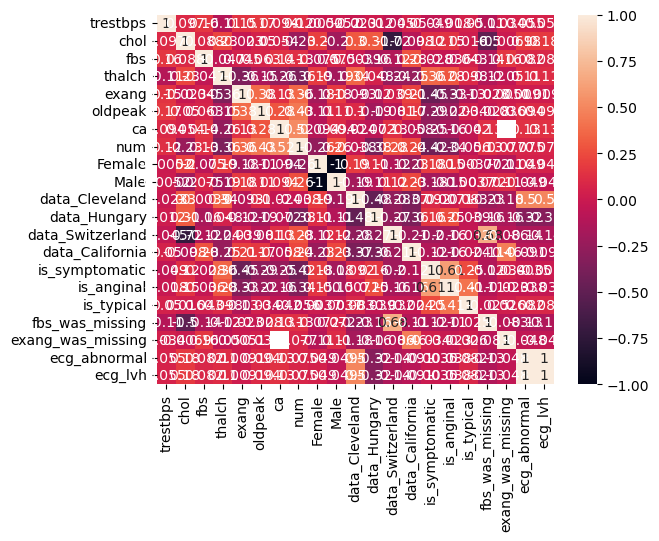

In [23]:
sns.heatmap(data.iloc[:,1:].corr(numeric_only=True), annot=True)